Using device: cuda
Loading models...
Analyzing Image: cju16ach3m1da0993r1dq3sn2Kvasir.png
Visualization saved to feature_pca_visualization.png


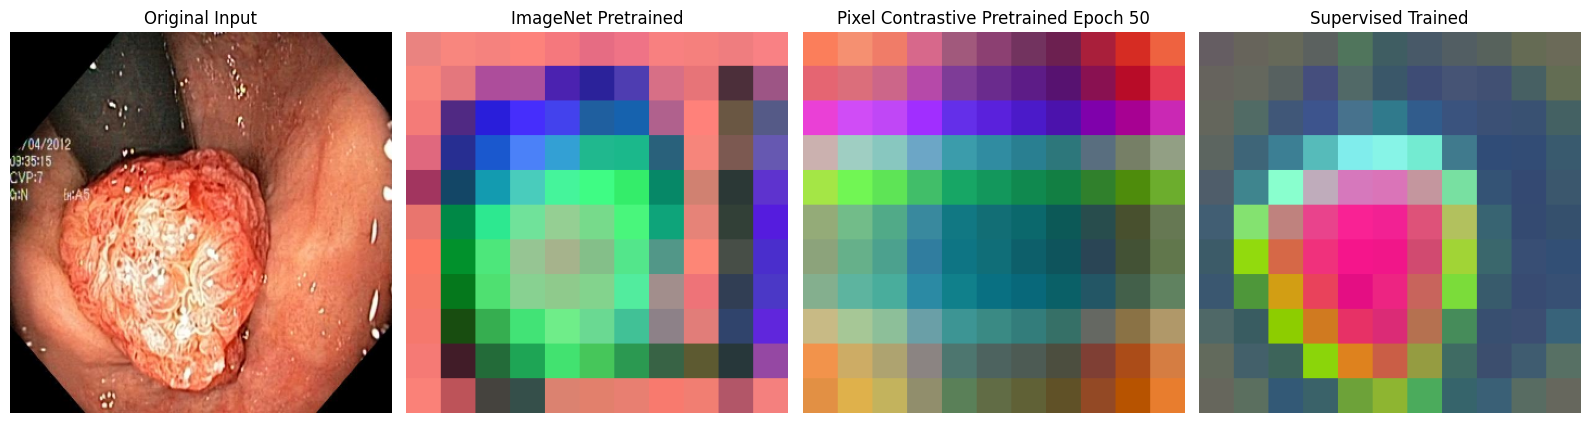

In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
import cv2
from tqdm import tqdm
from lib.pvtv2 import pvt_v2_b2


def get_pca_features(feature_map):
    """
    將高維特徵圖降維成 3 通道 RGB 圖像以便人眼觀察
    feature_map: (1, C, H, W)
    Returns: (H, W, 3) normalized RGB image (numpy)
    """
    b, c, h, w = feature_map.shape
    # Flatten: (H*W, C)
    features = feature_map.squeeze(0).permute(1, 2, 0).reshape(-1, c)
    features_np = features.detach().cpu().numpy()
    
    # Standardize (Z-score normalization) 讓 PCA 效果更好
    features_np = (features_np - features_np.mean(0)) / (features_np.std(0) + 1e-8)
    
    # PCA: Project to Top 3 Principal Components
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(features_np)
    
    # Min-Max Normalize to 0-1 for Visualization
    pca_features = (pca_features - pca_features.min()) / (pca_features.max() - pca_features.min())
    
    # Reshape back to spatial dimensions (H, W, 3)
    pca_img = pca_features.reshape(h, w, 3)
    return pca_img

def visualize_feature_pca(config):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # 1. 準備模型
    print("Loading models...")
    models = {}
    
    # (A) ImageNet Init (Baseline Anchor)
    model_img = pvt_v2_b2().to(device)
    img_path = '/home/U116med/wch_code/cascade/weights/pvt_v2_b2.pth' # 請確認路徑
    if os.path.exists(img_path):
        model_img.load_state_dict(torch.load(img_path, weights_only=True), strict=False)
    else:
        print(f"[Warning] ImageNet weights not found at {img_path}")
    model_img.eval()
    models['ImageNet Pretrained'] = model_img

    # (B) Contrastive Init
    model_con = pvt_v2_b2().to(device)
    con_path = '/home/U116med/wch_code/cascade/models/pretrain/pretrain_epoch_50.pth' # 請確認路徑
    if os.path.exists(con_path):
        model_con.load_state_dict(torch.load(con_path, weights_only=True), strict=False)
    else:
        print(f"[Warning] Contrastive weights not found at {con_path}")
    model_con.eval()
    models['Pixel Contrastive Pretrained Epoch 50'] = model_con
    
    # (C) Supervised Baseline (Stage 3 Best)
    model_sup = pvt_v2_b2().to(device)
    sup_path = '/home/U116med/wch_code/cascade/models/prototype_cascade/prototype_kl_loss_0.1_fb_44/best.pth'
    if os.path.exists(sup_path):
        ckpt = torch.load(sup_path, weights_only=True)
        # 處理 state_dict key 可能不匹配的問題
        state_dict = {}
        for k, v in ckpt.items():
            new_k = k.replace('module.', '').replace('backbone.', '') # 移除常見前綴
            if new_k in model_sup.state_dict():
                state_dict[new_k] = v
        model_sup.load_state_dict(state_dict, strict=False)
    else:
        print(f"[Warning] Supervised weights not found at {sup_path}")
    model_sup.eval()
    models['Supervised Trained'] = model_sup

    # 2. 挑選一張測試圖片
    # 建議挑選一張有明顯息肉結構的圖
    img_dir = config['val_image_dir']
    images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')])
    
    if len(images) > 0:
        # 這裡預設拿第一張，您可以改成指定檔名例如 'cju0qkwl35piu0993l0dewei2.jpg'
        #target_img_name = images[0] 
        target_img_name = 'cju16ach3m1da0993r1dq3sn2Kvasir.png'
        img_path = os.path.join(img_dir, target_img_name)
        print(f"Analyzing Image: {target_img_name}")
    else:
        print("No images found!")
        return

    # 3. 預處理
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Normalize using ImageNet mean/std
    img_tensor = torch.from_numpy(img_rgb).float().permute(2, 0, 1).unsqueeze(0).to(device)
    img_tensor = F.interpolate(img_tensor, size=(352, 352), mode='bilinear')
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device) * 255
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device) * 255
    input_tensor = (img_tensor - mean) / std

    # 4. 提取特徵並執行 PCA
    results = {}
    with torch.no_grad():
        for name, model in models.items():
            # PVTv2 forward 回傳四個 stage 的特徵，取最後一個 [-1] 代表最高級語義
            outs = model(input_tensor)
            feat = outs[-1] 
            
            # 執行 PCA 轉換
            pca_img = get_pca_features(feat)
            results[name] = pca_img

    # 5. 繪圖
    plt.figure(figsize=(16, 5))
    
    # Original
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.resize(img_rgb, (352, 352)))
    plt.title("Original Input")
    plt.axis('off')
    
    # Models
    idx = 2
    for name, pca_img in results.items():
        plt.subplot(1, 4, idx)
        pca_img_resized = cv2.resize(pca_img, (352, 352), interpolation=cv2.INTER_NEAREST)
        plt.imshow(pca_img_resized)
        plt.title(f"{name}")
        plt.axis('off')
        idx += 1
        
    plt.tight_layout()
    save_name = 'feature_pca_visualization.png'
    plt.savefig(save_name, dpi=300)
    print(f"Visualization saved to {save_name}")

if __name__ == '__main__':
    config = {
        'val_image_dir': '/home/U116med/data/polyp/TestDataset/test/images/',
    }
    visualize_feature_pca(config)